In [1]:
pip install pybullet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 MB 8.0 MB/s eta 0:00:00


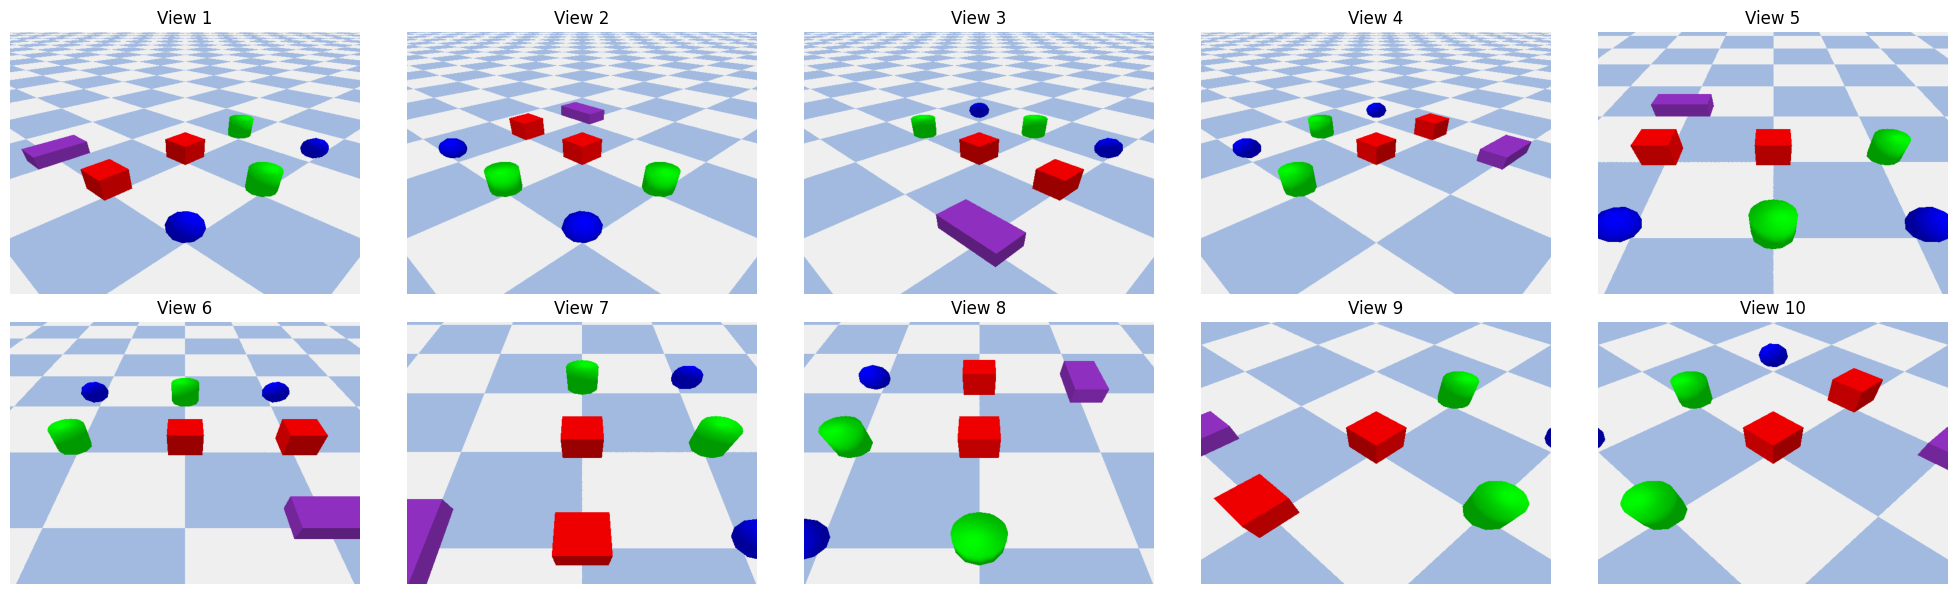

✅ Accuracy: 0.29411764705882354
📊 Confusion Matrix:
 [[9 0 0 0 0]
 [6 0 0 0 0]
 [6 0 1 0 0]
 [4 0 0 0 0]
 [8 0 0 0 0]]
📁 Classes: ['cube', 'cylinder', 'pyramid', 'rectangle', 'sphere']


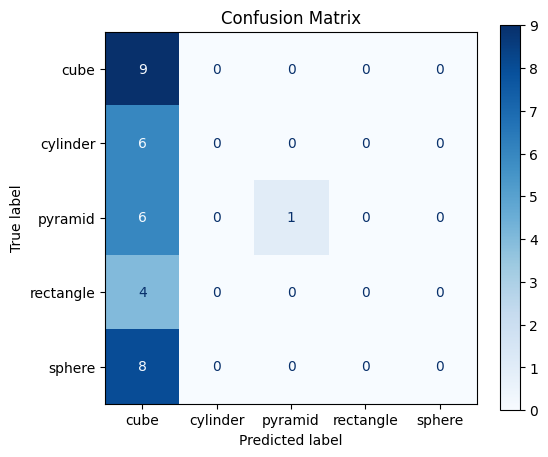

In [37]:
# STEP 1: Install required libraries
!pip install pybullet torchvision scikit-learn matplotlib

# STEP 2: Import libraries
import pybullet as p
import pybullet_data
import os, time, shutil
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# STEP 3: Create URDF Models
os.makedirs("urdf_models", exist_ok=True)

# Cube URDF
with open("urdf_models/cube.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="cube">
  <link name="cube_link">
    <visual>
      <geometry><box size="0.3 0.3 0.3"/></geometry>
      <origin xyz="0 0 0.15"/>
      <material name="red"><color rgba="1 0 0 1"/></material>
    </visual>
  </link>
</robot>''')

# Sphere URDF
with open("urdf_models/sphere.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="sphere">
  <link name="sphere_link">
    <visual>
      <geometry><sphere radius="0.15"/></geometry>
      <origin xyz="0 0 0.15"/>
      <material name="blue"><color rgba="0 0 1 1"/></material>
    </visual>
  </link>
</robot>''')

# Cylinder URDF
with open("urdf_models/cylinder.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="cylinder">
  <link name="cylinder_link">
    <visual>
      <geometry><cylinder radius="0.15" length="0.3"/></geometry>
      <origin xyz="0 0 0.15"/>
      <material name="green"><color rgba="0 1 0 1"/></material>
    </visual>
  </link>
</robot>''')

# Rectangle URDF
with open("urdf_models/rectangle.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="rectangle">
  <link name="rectangle_link">
    <visual>
      <geometry><box size="0.6 0.3 0.2"/></geometry>
      <origin xyz="0 0 0.1"/>
      <material name="purple"><color rgba="0.6 0.2 0.8 1"/></material>
    </visual>
  </link>
</robot>''')

# Pyramid Mesh + URDF
with open("urdf_models/pyramid.obj", "w") as f:
    f.write('''v -0.5 0 0.5\nv 0.5 0 0.5\nv 0.5 0 -0.5\nv -0.5 0 -0.5\nv 0.0 1 0.0
f 1 2 3\nf 1 3 4\nf 1 2 5\nf 2 3 5\nf 3 4 5\nf 4 1 5''')

with open("urdf_models/pyramid.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="pyramid">
  <link name="pyramid_link">
    <visual>
      <geometry><mesh filename="urdf_models/pyramid.obj" scale="0.5 0.5 0.5"/></geometry>
      <origin xyz="0 0 0.25"/>
      <material name="yellow"><color rgba="1 1 0 1"/></material>
    </visual>
  </link>
</robot>''')

# STEP 4: Load Objects in PyBullet Simulation
p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.loadURDF("plane.urdf")

shapes = [
    "cube.urdf", "cube.urdf",
    "cylinder.urdf", "cylinder.urdf",
    "sphere.urdf", "sphere.urdf",
    "pyramid.urdf",
    "rectangle.urdf"
]
positions = [
    [0, 0, 0.1], [1, 0, 0.1],
    [-1, 0, 0.1], [0, 1, 0.1],
    [1, 1, 0.1], [-1, 1, 0.1],
    [0, -1, 0.1],
    [1, -1, 0.1]
]

for shape, pos in zip(shapes, positions):
    p.loadURDF(f"urdf_models/{shape}", basePosition=pos)

for _ in range(240):
    p.stepSimulation()
    time.sleep(1/240)

# STEP 5: Capture Camera Views
os.makedirs("dataset_views", exist_ok=True)
camera_positions = [
    [2, 2, 2], [-2, 2, 2], [2, -2, 2], [-2, -2, 2],
    [0, 2, 2], [0, -2, 2], [1.5, 0, 2], [-1.5, 0, 2],
    [1, 1, 2], [-1, -1, 2]
]

for i, pos in enumerate(camera_positions):
    view_matrix = p.computeViewMatrix(pos, [0, 0, 0], [0, 0, 1])
    proj_matrix = p.computeProjectionMatrixFOV(60, 1, 0.1, 100)
    _, _, rgb, _, _ = p.getCameraImage(640, 480, view_matrix, proj_matrix)
    Image.fromarray(rgb).save(f"dataset_views/view_{i+1}.png")

p.disconnect()

# STEP 6: Display Camera Views
fig, axs = plt.subplots(2, 5, figsize=(20, 6))
for i in range(10):
    img = Image.open(f"dataset_views/view_{i+1}.png")
    axs[i // 5][i % 5].imshow(img)
    axs[i // 5][i % 5].axis('off')
    axs[i // 5][i % 5].set_title(f"View {i+1}")
plt.tight_layout()
plt.show()

# STEP 7: Organize Dummy Dataset
classes = ["cube", "cylinder", "sphere", "pyramid", "rectangle"]
for c in classes:
    os.makedirs(f"dataset/{c}", exist_ok=True)

shutil.copy("dataset_views/view_1.png", "dataset/cube/img1.png")
shutil.copy("dataset_views/view_2.png", "dataset/cube/img2.png")
shutil.copy("dataset_views/view_3.png", "dataset/cylinder/img3.png")
shutil.copy("dataset_views/view_4.png", "dataset/cylinder/img4.png")
shutil.copy("dataset_views/view_5.png", "dataset/sphere/img5.png")
shutil.copy("dataset_views/view_6.png", "dataset/sphere/img6.png")
shutil.copy("dataset_views/view_7.png", "dataset/pyramid/img7.png")
shutil.copy("dataset_views/view_8.png", "dataset/rectangle/img8.png")

# STEP 8: Classification
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
dataset = ImageFolder("dataset", transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)
model.eval()

preds, targets = [], []
with torch.no_grad():
    for inputs, labels in dataloader:
        outputs = model(inputs.to(device))
        _, predicted = torch.max(outputs, 1)
        preds.extend(predicted.cpu().numpy())
        targets.extend(labels.numpy())

# STEP 9: Confusion Matrix
acc = accuracy_score(targets, preds)
cm = confusion_matrix(targets, preds)
print(" Accuracy:", acc)
print(" Confusion Matrix:\n", cm)
print(" Classes:", dataset.classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


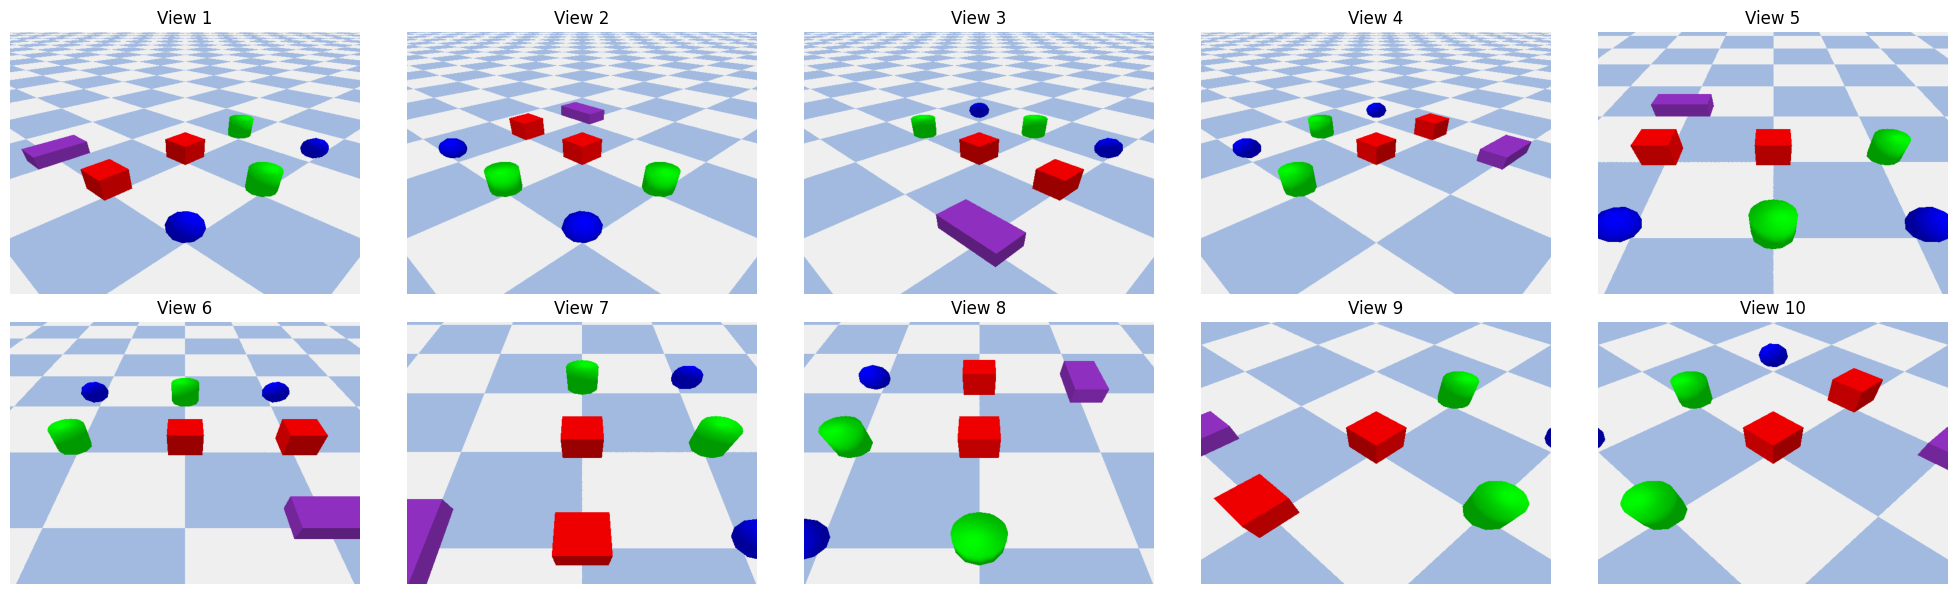

 Accuracy: 0.19736842105263158
 Confusion Matrix:
 [[13  0  0  8  0]
 [ 4  0  0 12  0]
 [ 6  0  0  6  0]
 [ 7  0  0  2  0]
 [15  0  0  3  0]]
 Classes: ['cube', 'cylinder', 'pyramid', 'rectangle', 'sphere']


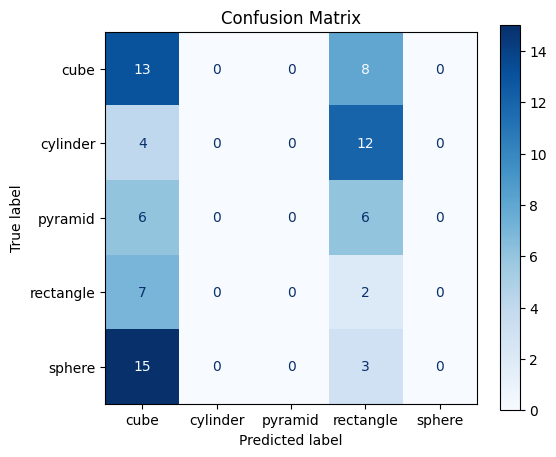

In [41]:
# STEP 1: Install required libraries
!pip install pybullet torchvision scikit-learn matplotlib

# STEP 2: Import libraries
import pybullet as p
import pybullet_data
import os, time, shutil
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# STEP 3: Create URDF Models
os.makedirs("urdf_models", exist_ok=True)

# Cube URDF
with open("urdf_models/cube.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="cube">
  <link name="cube_link">
    <visual>
      <geometry><box size="0.3 0.3 0.3"/></geometry>
      <origin xyz="0 0 0.15"/>
      <material name="red"><color rgba="1 0 0 1"/></material>
    </visual>
  </link>
</robot>''')

# Sphere URDF
with open("urdf_models/sphere.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="sphere">
  <link name="sphere_link">
    <visual>
      <geometry><sphere radius="0.15"/></geometry>
      <origin xyz="0 0 0.15"/>
      <material name="blue"><color rgba="0 0 1 1"/></material>
    </visual>
  </link>
</robot>''')

# Cylinder URDF
with open("urdf_models/cylinder.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="cylinder">
  <link name="cylinder_link">
    <visual>
      <geometry><cylinder radius="0.15" length="0.3"/></geometry>
      <origin xyz="0 0 0.15"/>
      <material name="green"><color rgba="0 1 0 1"/></material>
    </visual>
  </link>
</robot>''')

# Rectangle URDF
with open("urdf_models/rectangle.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="rectangle">
  <link name="rectangle_link">
    <visual>
      <geometry><box size="0.6 0.3 0.2"/></geometry>
      <origin xyz="0 0 0.1"/>
      <material name="purple"><color rgba="0.6 0.2 0.8 1"/></material>
    </visual>
  </link>
</robot>''')

# Pyramid URDF and Mesh
with open("urdf_models/pyramid.obj", "w") as f:
    f.write('''v -0.5 0 0.5\nv 0.5 0 0.5\nv 0.5 0 -0.5\nv -0.5 0 -0.5\nv 0.0 1 0.0
f 1 2 3\nf 1 3 4\nf 1 2 5\nf 2 3 5\nf 3 4 5\nf 4 1 5''')

with open("urdf_models/pyramid.urdf", "w") as f:
    f.write('''<?xml version="1.0"?><robot name="pyramid">
  <link name="pyramid_link">
    <visual>
      <geometry><mesh filename="urdf_models/pyramid.obj" scale="0.5 0.5 0.5"/></geometry>
      <origin xyz="0 0 0.25"/>
      <material name="yellow"><color rgba="1 1 0 1"/></material>
    </visual>
  </link>
</robot>''')

# STEP 4: Load into PyBullet
p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.loadURDF("plane.urdf")

shapes = [
    "cube.urdf", "cube.urdf",
    "cylinder.urdf", "cylinder.urdf",
    "sphere.urdf", "sphere.urdf",
    "pyramid.urdf",
    "rectangle.urdf"
]
positions = [
    [0, 0, 0.1], [1, 0, 0.1],
    [-1, 0, 0.1], [0, 1, 0.1],
    [1, 1, 0.1], [-1, 1, 0.1],
    [0, -1, 0.1],
    [1, -1, 0.1]
]

for shape, pos in zip(shapes, positions):
    p.loadURDF(f"urdf_models/{shape}", basePosition=pos)

for _ in range(240):
    p.stepSimulation()
    time.sleep(1/240)

# STEP 5: Capture Camera Views
os.makedirs("dataset_views", exist_ok=True)
camera_positions = [
    [2, 2, 2], [-2, 2, 2], [2, -2, 2], [-2, -2, 2],
    [0, 2, 2], [0, -2, 2], [1.5, 0, 2], [-1.5, 0, 2],
    [1, 1, 2], [-1, -1, 2]
]

for i, pos in enumerate(camera_positions):
    view_matrix = p.computeViewMatrix(pos, [0, 0, 0], [0, 0, 1])
    proj_matrix = p.computeProjectionMatrixFOV(60, 1, 0.1, 100)
    _, _, rgb, _, _ = p.getCameraImage(640, 480, view_matrix, proj_matrix)
    Image.fromarray(rgb).save(f"dataset_views/view_{i+1}.png")

p.disconnect()

# STEP 6: Display Views
fig, axs = plt.subplots(2, 5, figsize=(20, 6))
for i in range(10):
    img = Image.open(f"dataset_views/view_{i+1}.png")
    axs[i // 5][i % 5].imshow(img)
    axs[i // 5][i % 5].axis('off')
    axs[i // 5][i % 5].set_title(f"View {i+1}")
plt.tight_layout()
plt.show()

# STEP 7: Organize Dataset Folders
classes = ["cube", "cylinder", "sphere", "pyramid", "rectangle"]
for c in classes:
    os.makedirs(f"dataset/{c}", exist_ok=True)

# Assign one image per class
shutil.copy("dataset_views/view_1.png", "dataset/cube/img1.png")
shutil.copy("dataset_views/view_2.png", "dataset/cube/img2.png")
shutil.copy("dataset_views/view_3.png", "dataset/cylinder/img3.png")
shutil.copy("dataset_views/view_4.png", "dataset/cylinder/img4.png")
shutil.copy("dataset_views/view_5.png", "dataset/sphere/img5.png")
shutil.copy("dataset_views/view_6.png", "dataset/sphere/img6.png")
shutil.copy("dataset_views/view_7.png", "dataset/pyramid/img7.png")
shutil.copy("dataset_views/view_8.png", "dataset/rectangle/img8.png")

# STEP 7B: Safely Duplicate Images
for i in range(1, 6):
    shutil.copy("dataset/cube/img1.png", f"dataset/cube/img_dup_{i}.png")
    shutil.copy("dataset/cube/img2.png", f"dataset/cube/img_dup_b{i}.png")
    shutil.copy("dataset/cylinder/img3.png", f"dataset/cylinder/img_dup_{i}.png")
    shutil.copy("dataset/cylinder/img4.png", f"dataset/cylinder/img_dup_b{i}.png")
    shutil.copy("dataset/sphere/img5.png", f"dataset/sphere/img_dup_{i}.png")
    shutil.copy("dataset/sphere/img6.png", f"dataset/sphere/img_dup_b{i}.png")
    shutil.copy("dataset/pyramid/img7.png", f"dataset/pyramid/img_dup_{i}.png")
    shutil.copy("dataset/rectangle/img8.png", f"dataset/rectangle/img_dup_{i}.png")

# STEP 8: Preprocessing with Augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
dataset = ImageFolder("dataset", transform=transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)

# STEP 9: ResNet18 Inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)
model.eval()

preds, targets = [], []
with torch.no_grad():
    for inputs, labels in dataloader:
        outputs = model(inputs.to(device))
        _, predicted = torch.max(outputs, 1)
        preds.extend(predicted.cpu().numpy())
        targets.extend(labels.numpy())

# STEP 10: Confusion Matrix & Accuracy
acc = accuracy_score(targets, preds)
cm = confusion_matrix(targets, preds)
print(" Accuracy:", acc)
print(" Confusion Matrix:\n", cm)
print(" Classes:", dataset.classes)

# Plot matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

